In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns




In [3]:
pd.read_csv("/content/netflix_titles_nov_2019.csv")

,show_id,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,type
0,81193313,Chocolate,NaN,"Ha Ji-won, Yoon Kye-sang, Jang Seung-jo, Kang ...",South Korea,"November 30, 2019",2019,TV-14,1 Season,"International TV Shows, Korean TV Shows, Roman...",Brought together by meaningful meals in the pa...,TV Show
1,81197050,Guatemala: Heart of the Mayan World,"Luis Ara, Ignacio Jaunsolo",Christian Morales,NaN,"November 30, 2019",2019,TV-G,67 min,"Documentaries, International Movies","From Sierra de las Minas to Esquipulas, explor...",Movie
2,81213894,The Zoya Factor,Abhishek Sharma,"Sonam Kapoor, Dulquer Salmaan, Sanjay Kapoor, ...",India,"November 30, 2019",2019,TV-14,135 min,"Comedies, Dramas, International Movies",A goofy copywriter unwittingly convinces the I...,Movie
3,81082007,Atlantics,Mati Diop,"Mama Sane, Amadou Mbow, Ibrahima Traore, Nicol...","France, Senegal, Belgium","November 29, 2019",2019,TV-14,106 min,"Dramas, Independent Movies, International Movies","Arranged to marry a rich man, young Ada is cru...",Movie
4,80213643,Chip and Potato,NaN,"Abigail Oliver, Andrea Libman, Briana Buckmast...","Canada, United Kingdom",NaN,2019,TV-Y,2 Seasons,Kids' TV,"Lovable pug Chip starts kindergarten, makes ne...",TV Show
...,...,...,...,...,...,...,...,...,...,...,...,...
5832,70141644,Mad Ron's Prevues from Hell,Jim Monaco,"Nick Pawlow, Jordu Schell, Jay Kushwara, Micha...",United States,"November 1, 2010",1987,NR,84 min,"Cult Movies, Horror Movies","This collection cherry-picks trailers, forgott...",Movie
5833,70127998,Splatter,Joe Dante,"Corey Feldman, Tony Todd, Tara Leigh, Erin Way...",United States,"November 18, 2009",2009,TV-14,29 min,Horror Movies,"After committing suicide, a washed-up rocker r...",Movie
5834,70084180,Just Another Love Story,Ole Bornedal,"Anders W. Berthelsen, Rebecka Hemse, Nikolaj L...",Denmark,"May 5, 2009",2007,NR,104 min,"Dramas, International Movies",When he causes a car accident that leaves a yo...,Movie
5835,70157452,Dinner for Five,NaN,NaN,United States,"February 4, 2008",2007,TV-MA,1 Season,Stand-Up Comedy & Talk Shows,"In each episode, four celebrities join host Jo...",TV Show


In [6]:
df = pd.read_csv("/content/netflix_titles_nov_2019.csv")
print("\n--- First 5 rows ---\n")
print(df.head())
print("\n--- DataFrame Info ---\n")
df.info()
print("\n--- Descriptive Statistics ---\n")
print(df.describe(include='all'))


--- First 5 rows ---

    show_id                                title                    director  \
0  81193313                            Chocolate                         NaN   
1  81197050  Guatemala: Heart of the Mayan World  Luis Ara, Ignacio Jaunsolo   
2  81213894                      The Zoya Factor             Abhishek Sharma   
3  81082007                            Atlantics                   Mati Diop   
4  80213643                      Chip and Potato                         NaN   

                                                cast  \
0  Ha Ji-won, Yoon Kye-sang, Jang Seung-jo, Kang ...   
1                                  Christian Morales   
2  Sonam Kapoor, Dulquer Salmaan, Sanjay Kapoor, ...   
3  Mama Sane, Amadou Mbow, Ibrahima Traore, Nicol...   
4  Abigail Oliver, Andrea Libman, Briana Buckmast...   

                    country         date_added  release_year rating  \
0               South Korea  November 30, 2019          2019  TV-14   
1                

### Data Cleaning

In [7]:
# Fill missing values in categorical columns with 'Unknown'
df['director'].fillna('Unknown', inplace=True)
df['cast'].fillna('Unknown', inplace=True)
df['country'].fillna('Unknown', inplace=True)

# Convert 'date_added' to datetime objects
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Handle missing 'date_added' entries if any resulted from coercion
df.dropna(subset=['date_added'], inplace=True)

# Process 'duration' column
# Separate Movies and TV Shows to handle duration differently
movies_df = df[df['type'] == 'Movie'].copy()
tvshows_df = df[df['type'] == 'TV Show'].copy()

# For movies, extract minutes and convert to integer
movies_df['duration_min'] = movies_df['duration'].str.replace(' min', '').astype(int)

# For TV shows, extract number of seasons and convert to integer
tvshows_df['num_seasons'] = tvshows_df['duration'].str.replace(' Season', '').str.replace('s', '').astype(int)

# Drop the original 'duration' column as we have processed it
m_df = movies_df.drop(columns=['duration'])
tv_df = tvshows_df.drop(columns=['duration'])

print("\n--- Missing values after filling ---\n")
print(df.isnull().sum())

print("\n--- Movies DataFrame head with duration_min ---\n")
display(m_df.head())

print("\n--- TV Shows DataFrame head with num_seasons ---\n")
display(tv_df.head())


--- Missing values after filling ---

show_id         0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          9
duration        0
listed_in       0
description     0
type            0
dtype: int64

--- Movies DataFrame head with duration_min ---



/tmp/ipykernel_5939/189699095.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['director'].fillna('Unknown', inplace=True)
/tmp/ipykernel_5939/189699095.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

,show_id,title,director,cast,country,date_added,release_year,rating,listed_in,description,type,duration_min
1,81197050,Guatemala: Heart of the Mayan World,"Luis Ara, Ignacio Jaunsolo",Christian Morales,Unknown,2019-11-30,2019,TV-G,"Documentaries, International Movies","From Sierra de las Minas to Esquipulas, explor...",Movie,67
2,81213894,The Zoya Factor,Abhishek Sharma,"Sonam Kapoor, Dulquer Salmaan, Sanjay Kapoor, ...",India,2019-11-30,2019,TV-14,"Comedies, Dramas, International Movies",A goofy copywriter unwittingly convinces the I...,Movie,135
3,81082007,Atlantics,Mati Diop,"Mama Sane, Amadou Mbow, Ibrahima Traore, Nicol...","France, Senegal, Belgium",2019-11-29,2019,TV-14,"Dramas, Independent Movies, International Movies","Arranged to marry a rich man, young Ada is cru...",Movie,106
5,81172754,Crazy people,Moses Inwang,"Ramsey Nouah, Chigul, Sola Sobowale, Ireti Doy...",Nigeria,2019-11-29,2018,TV-14,"Comedies, International Movies, Thrillers",Nollywood star Ramsey Nouah learns that someon...,Movie,107
6,81120982,I Lost My Body,Jérémy Clapin,"Hakim Faris, Victoire Du Bois, Patrick d'Assum...",France,2019-11-29,2019,TV-MA,"Dramas, Independent Movies, International Movies","Romance, mystery and adventure intertwine as a...",Movie,81



--- TV Shows DataFrame head with num_seasons ---



,show_id,title,director,cast,country,date_added,release_year,rating,listed_in,description,type,num_seasons
0,81193313,Chocolate,Unknown,"Ha Ji-won, Yoon Kye-sang, Jang Seung-jo, Kang ...",South Korea,2019-11-30,2019,TV-14,"International TV Shows, Korean TV Shows, Roman...",Brought together by meaningful meals in the pa...,TV Show,1
11,81094391,Sugar Rush Christmas,Unknown,"Hunter March, Candace Nelson, Adriano Zumbo",United States,2019-11-29,2019,TV-PG,Reality TV,"It's everything you love about ""Sugar Rush"" – ...",TV Show,1
13,81152641,The Charming Stepmom,Unknown,"Shahkrit Yamnarm, View Wannarot Sontichai, Kri...",Unknown,2019-11-29,2019,TV-14,"International TV Shows, Romantic TV Shows, TV ...",A quirky fashion student becomes the nanny of ...,TV Show,1
15,80990849,The Movies That Made Us,Unknown,Unknown,United States,2019-11-29,2019,TV-MA,Docuseries,These blockbusters brought us together and gav...,TV Show,1
17,80156799,Levius,Unknown,"Nobunaga Shimazaki, Junichi Suwabe, Takahiro S...",Japan,2019-11-28,2019,TV-14,"Anime Series, International TV Shows",Young Levius rises through the ranks in the br...,TV Show,1


### Removing Duplicate Rows

In [8]:
print(f"Shape of DataFrame before dropping duplicates: {df.shape}")
df.drop_duplicates(inplace=True)
print(f"Shape of DataFrame after dropping duplicates: {df.shape}")

Shape of DataFrame before dropping duplicates: (5195, 12)
Shape of DataFrame after dropping duplicates: (5195, 12)


### Creating NumPy Arrays

In [9]:
# Create a 1D array
arr1d = np.array([1, 2, 3, 4, 5, 6])
print("1D Array:", arr1d)
print("Shape of 1D Array:", arr1d.shape)

# Create a 2D array (matrix)
arr2d = np.array([[1, 2, 3], [4, 5, 6]])
print("\n2D Array:\n", arr2d)
print("Shape of 2D Array:", arr2d.shape)

# Create an array with a specified range
arr_range = np.arange(10, 20, 2) # Start, Stop (exclusive), Step
print("\nArray using arange():", arr_range)

# Create an array of zeros
arr_zeros = np.zeros((3, 4)) # 3 rows, 4 columns
print("\nArray of Zeros (3x4):\n", arr_zeros)

# Create an array of ones
arr_ones = np.ones((2, 3))
print("\nArray of Ones (2x3):\n", arr_ones)

# Create an array with random values
arr_rand = np.random.rand(2, 2) # 2x2 array with random floats between 0 and 1
print("\nRandom 2x2 Array:\n", arr_rand)

1D Array: [1 2 3 4 5 6]
Shape of 1D Array: (6,)

2D Array:
 [[1 2 3]
 [4 5 6]]
Shape of 2D Array: (2, 3)

Array using arange(): [10 12 14 16 18]

Array of Zeros (3x4):
 [[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]

Array of Ones (2x3):
 [[1. 1. 1.]
 [1. 1. 1.]]

Random 2x2 Array:
 [[0.734803   0.68961937]
 [0.74922802 0.32910522]]


#### Basic Array Operations

In [10]:
# Reshape an array
arr_reshaped = arr1d.reshape(2, 3)
print("\nReshaped 1D Array to 2x3:\n", arr_reshaped)

# Element-wise operations
result_add = arr1d + 10
print("\nArray + 10:", result_add)

result_multiply = arr2d * 2
print("\n2D Array * 2:\n", result_multiply)

# Dot product of two arrays (if compatible)
# For example, if we create another array for dot product
arr_b = np.array([[7, 8], [9, 10], [11, 12]])
try:
    dot_product = np.dot(arr_reshaped, arr_b)
    print("\nDot product of reshaped array and arr_b:\n", dot_product)
except ValueError as e:
    print(f"\nCould not perform dot product: {e}")


Reshaped 1D Array to 2x3:
 [[1 2 3]
 [4 5 6]]

Array + 10: [11 12 13 14 15 16]

2D Array * 2:
 [[ 2  4  6]
 [ 8 10 12]]

Dot product of reshaped array and arr_b:
 [[ 58  64]
 [139 154]]


### NumPy Array Indexing and Slicing

In [23]:
# Let's use our previously created arr1d and arr2d for demonstration
print("Original 1D Array (arr1d):\n", arr1d)
print("Original 2D Array (arr2d):\n", arr2d)

Original 1D Array (arr1d):
 [1 2 3 4 5 6]
Original 2D Array (arr2d):
 [[1 2 3]
 [4 5 6]]


#### 1. Indexing (Accessing individual elements)

In [12]:
# Accessing elements in a 1D array
print("First element of arr1d:", arr1d[0])
print("Last element of arr1d:", arr1d[-1])

# Accessing elements in a 2D array (row, column)
print("\nElement at row 0, column 1 of arr2d:", arr2d[0, 1]) # Value: 2
print("Element at row 1, column 2 of arr2d:", arr2d[1, 2]) # Value: 6

First element of arr1d: 1
Last element of arr1d: 6

Element at row 0, column 1 of arr2d: 2
Element at row 1, column 2 of arr2d: 6


#### 2. Slicing (Accessing sub-arrays)

In [13]:
# Slicing a 1D array: [start:end:step]
print("\nFirst three elements of arr1d:", arr1d[0:3]) # or arr1d[:3]
print("Elements from index 2 onwards of arr1d:", arr1d[2:])
print("Every other element of arr1d:", arr1d[::2])

# Slicing a 2D array: [row_start:row_end, col_start:col_end]
print("\nFirst row of arr2d:", arr2d[0, :])
print("Second column of arr2d:", arr2d[:, 1])
print("\nSub-array from arr2d (first row, first two columns):\n", arr2d[0:1, 0:2])
print("\nAll rows, last column of arr2d:", arr2d[:, -1])


First three elements of arr1d: [1 2 3]
Elements from index 2 onwards of arr1d: [3 4 5 6]
Every other element of arr1d: [1 3 5]

First row of arr2d: [1 2 3]
Second column of arr2d: [2 5]

Sub-array from arr2d (first row, first two columns):
 [[1 2]]

All rows, last column of arr2d: [3 6]


### NumPy Data Aggregation - Revisited

NumPy provides powerful functions for aggregating data, such as finding the sum, mean, minimum, maximum, and standard deviation of array elements. For multi-dimensional arrays, the `axis` parameter allows you to specify whether to aggregate across rows (columns) or columns (rows).

In [14]:
print("1D Array (arr1d):", arr1d)
print("2D Array (arr2d):\n", arr2d)

print("\n--- Aggregation on 1D Array (arr1d) ---")
print("Sum:", np.sum(arr1d))
print("Mean:", np.mean(arr1d))
print("Min:", np.min(arr1d))
print("Max:", np.max(arr1d))
print("Std Dev:", np.std(arr1d))

print("\n--- Aggregation on 2D Array (arr2d) ---")
# Sum of all elements in the 2D array
print("Sum of all elements:", np.sum(arr2d))

# Sum along axis=0 (columns) - aggregates down rows
print("Sum of each column (axis=0):", np.sum(arr2d, axis=0))

# Mean along axis=1 (rows) - aggregates across columns
print("Mean of each row (axis=1):", np.mean(arr2d, axis=1))

# Minimum along axis=0 (columns)
print("Minimum of each column (axis=0):", np.min(arr2d, axis=0))

1D Array (arr1d): [1 2 3 4 5 6]
2D Array (arr2d):
 [[1 2 3]
 [4 5 6]]

--- Aggregation on 1D Array (arr1d) ---
Sum: 21
Mean: 3.5
Min: 1
Max: 6
Std Dev: 1.707825127659933

--- Aggregation on 2D Array (arr2d) ---
Sum of all elements: 21
Sum of each column (axis=0): [5 7 9]
Mean of each row (axis=1): [2. 5.]
Minimum of each column (axis=0): [1 2 3]


## Data Analysis and Visualization

### 1. Univariate Analysis

#### Content Type Distribution (Movies vs. TV Shows)

/tmp/ipykernel_5939/1772931185.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='type', data=df, palette='viridis')


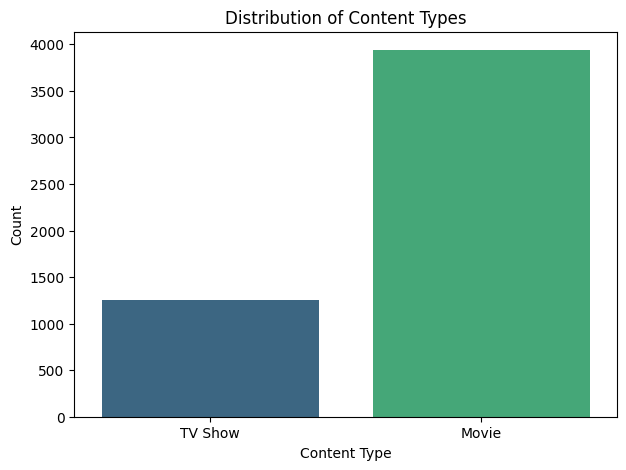

In [15]:
plt.figure(figsize=(7, 5))
sns.countplot(x='type', data=df, palette='viridis')
plt.title('Distribution of Content Types')
plt.xlabel('Content Type')
plt.ylabel('Count')
plt.show()

#### Top 10 Countries with Content

/tmp/ipykernel_5939/3412042445.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.index, y=top_countries.values, palette='magma')


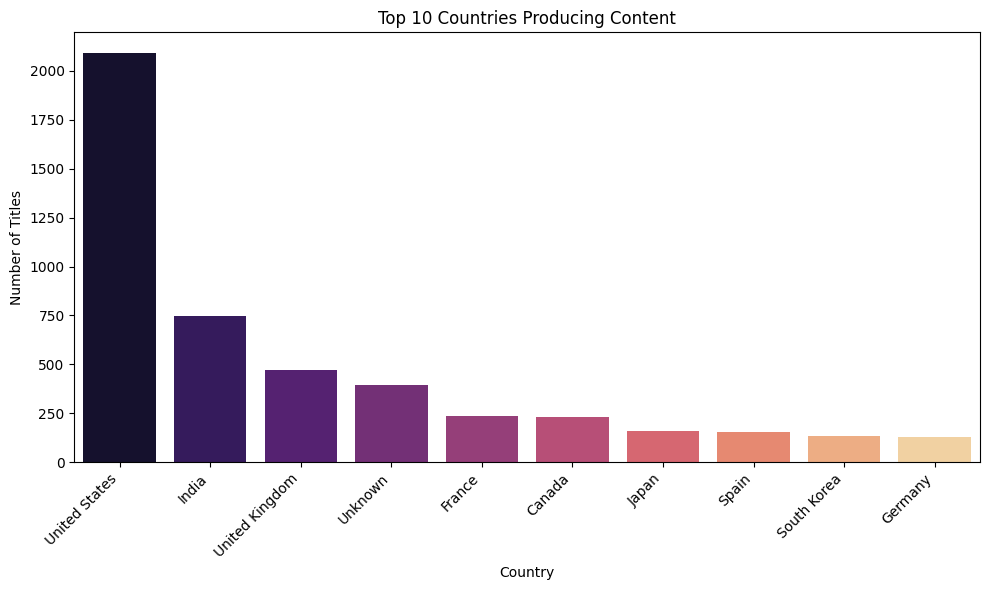

In [16]:
# Extract individual countries, handling multiple countries per entry
countries_df = df['country'].apply(lambda x: str(x).split(', ')).explode()
top_countries = countries_df.value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_countries.index, y=top_countries.values, palette='magma')
plt.title('Top 10 Countries Producing Content')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Release Year Distribution

/tmp/ipykernel_5939/2448261150.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df['release_year'], bins=30, kde=True, palette='coolwarm')


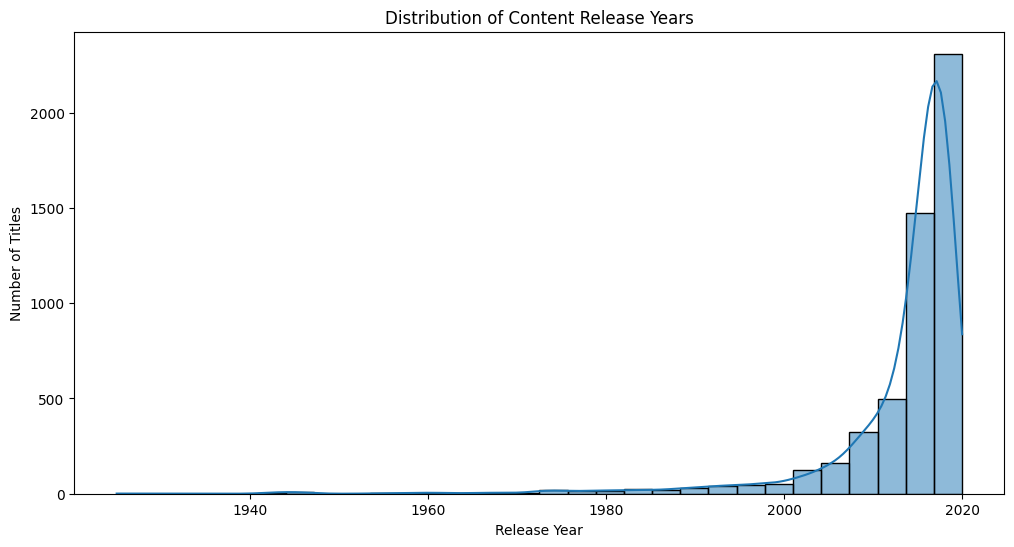

In [17]:
plt.figure(figsize=(12, 6))
sns.histplot(df['release_year'], bins=30, kde=True, palette='coolwarm')
plt.title('Distribution of Content Release Years')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.show()

#### Rating Distribution

/tmp/ipykernel_5939/869211685.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=df, order=df['rating'].value_counts().index, palette='rocket')


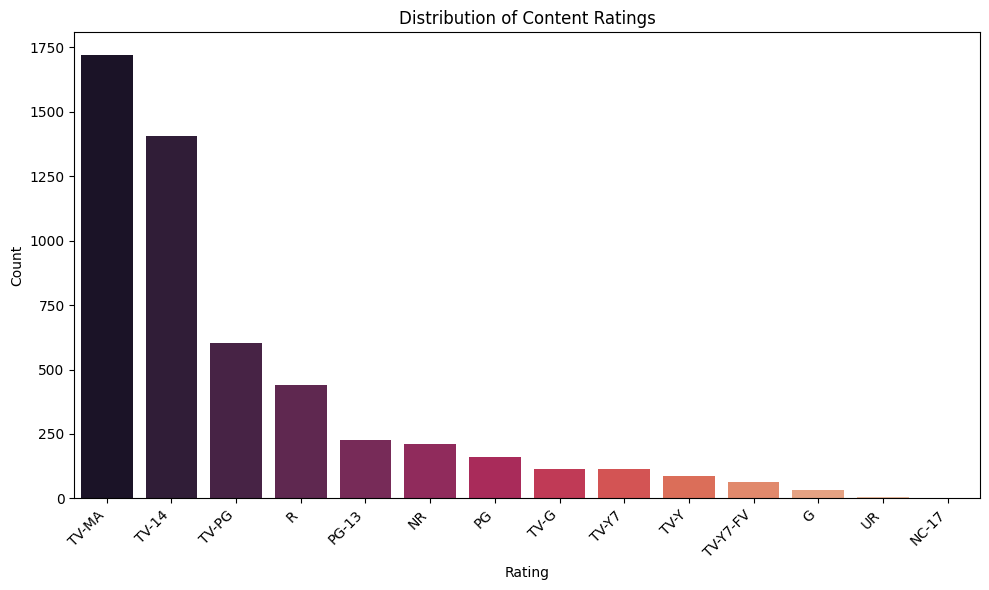

In [18]:
plt.figure(figsize=(10, 6))
sns.countplot(x='rating', data=df, order=df['rating'].value_counts().index, palette='rocket')
plt.title('Distribution of Content Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Movie Duration Distribution

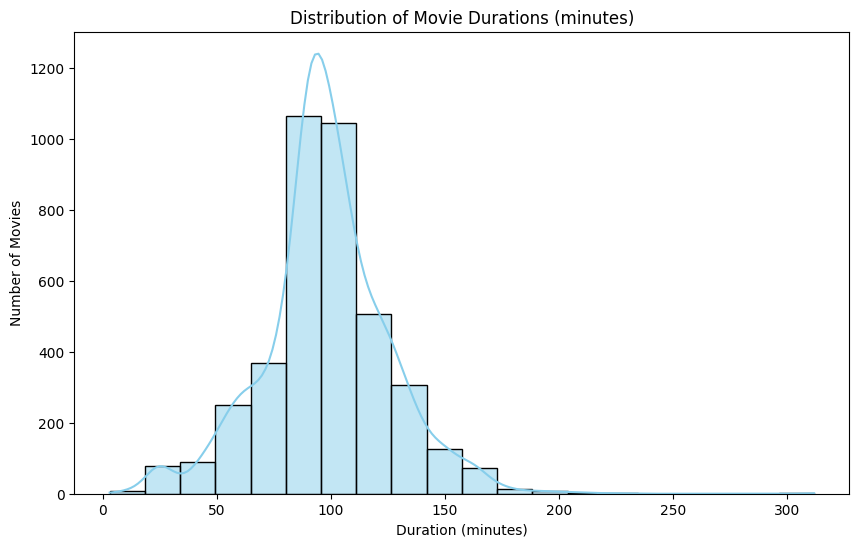

In [19]:
plt.figure(figsize=(10, 6))
sns.histplot(m_df['duration_min'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Movie Durations (minutes)')
plt.xlabel('Duration (minutes)')
plt.ylabel('Number of Movies')
plt.show()

#### TV Show Seasons Distribution

/tmp/ipykernel_5939/2496500665.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='num_seasons', data=tv_df, order=tv_df['num_seasons'].value_counts().index, palette='viridis')


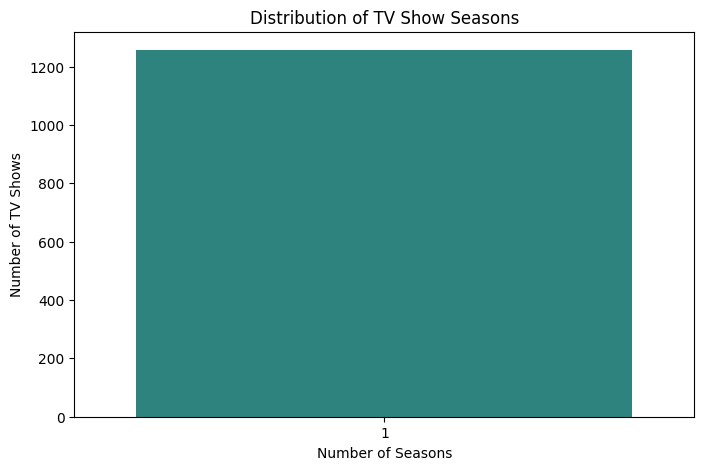

In [22]:
plt.figure(figsize=(8,5))
sns.countplot(x='num_seasons', data=tv_df, order=tv_df['num_seasons'].value_counts().index, palette='viridis')
plt.title('Distribution of TV Show Seasons')
plt.xlabel('Number of Seasons')
plt.ylabel('Number of TV Shows')
plt.show()

In [ ]:
df.to_csv("cleaned_netflix_titles_nov_2019.csv",index=False)
from google.colab import files
files.desktop("cleaned_netflix_titles_nov_2019.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>